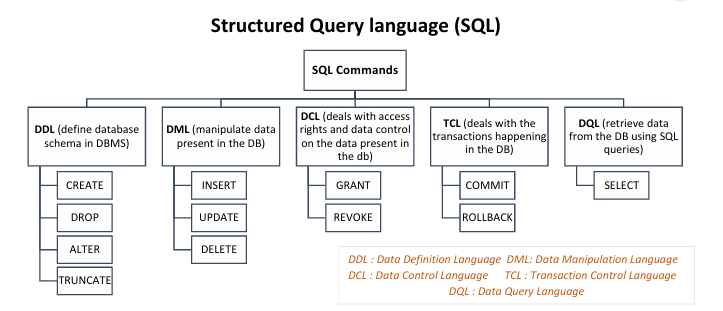

DDL

create table table_name-->

* (column_name datatype constraint)


drop table table_name-->


alter table table_name-->

* add column_name datatype constraint
* drop column column_name
* alter column column_name datatype 



DML

insert into table_name-->

* (column_names) values( column_values)

update table_name-->

* set column_name = new_value where condition

delete from table_name-->

* where condition

DQL

select column_name from table_name-->

* where condition

select * from table_name-->

* where condition

Standard Sequence of SQL Keywords
WITH (Optional)
Defines Common Table Expressions (CTEs) for reusable subqueries.

SELECT
Specifies the columns or expressions to retrieve.

FROM
Identifies the primary table(s) to query.

JOIN (with ON)
Combines data from multiple tables based on a condition.

WHERE
Filters individual rows before grouping or aggregation.

GROUP BY
Groups rows by one or more columns for aggregation.

HAVING
Filters groups after aggregation.

ORDER BY
Sorts the final result set.

LIMIT (Optional, depending on database)
Restricts the number of rows returned.

OFFSET (Optional, paired with LIMIT)
Skips a specified number of rows before applying LIMIT.

Execution Order (Logical Processing)
Databases process these keywords in a different order than they appear in the query:


FROM and JOIN (build the working table)

WHERE (filter rows)

GROUP BY (group rows)

HAVING (filter groups)

SELECT (project columns)

ORDER BY (sort results)

LIMIT/OFFSET (restrict output)

In [1]:
import mysql.connector

mydb2 = mysql.connector.connect(  #establishing the connection
    host = "localhost",
    user="root",
    passwd = "mYsql@2022",
    database = "sample2"
)

In [2]:
mydb2

In [3]:
cursor = mydb2.cursor(buffered=True)

In [ ]:
# Buffered Cursors (buffered=True)
# A buffered cursor retrieves and stores all the rows from the query result set in memory. This means that:
# The entire result set is fetched from the database and stored in memory when you execute a query.
# You can iterate over the result set multiple times without re-executing the query.
# You can use methods like fetchone(), fetchmany(), and fetchall() to retrieve rows from the result set.
# Buffered cursors are useful when:
# You need to iterate over the result set multiple times.
# You need to access rows randomly (e.g., using fetchone() and then fetchone() again).
# You're working with small to medium-sized result sets.
# Unbuffered Cursors (buffered=False)
# An unbuffered cursor retrieves rows from the query result set one at a time, without storing the entire result set in memory. This means that:
# Rows are fetched from the database as you iterate over the result set.
# You can only iterate over the result set once; if you try to iterate again, you'll need to re-execute the query.
# You can only use methods like fetchone() and fetchmany() to retrieve rows from the result set.
# Unbuffered cursors are useful when:
# You're working with very large result sets and don't want to consume excessive memory.
# You only need to iterate over the result set once.

In [4]:
cursor

Use the database 

In [6]:
cursor.execute("use sample2")

. Create table 

In [8]:
cursor.execute("""create table customer  
                    ( 
                    customer_id int AUTO_INCREMENT primary key, 
                    customer_number int not null unique check (customer_number>0), 
                    lastname varchar(30) not null, 
                    firstname varchar(30) not null, 
                    area_code int default 71000, 
                    address varchar(50), 
                    country varchar(50) default 'Malaysia' 
                    )""")

Insert values into table 

In [ ]:
cursor.execute("""insert into customer(customer_number,lastname,firstname,area_code,address,country) 
               values 
                (100,'Fang Ying','Sham','418999','sdadasfdfd',default), 
                (200,'Mei Mei','Tan',default,'adssdsadsd','Thailand'), 
                (300,'Albert','John',default,'dfdsfsdf',default)  """)

must commit after executing insertions

In [11]:
mydb2.commit()

In [19]:
# -- display all records 
cursor.execute("""select * from customer""")

fetchall() after selecting

In [18]:
cursor.fetchall()

[(1, 100, 'Fang Ying', 'Sham', 418999, 'sdadasfdfd', 'Malaysia'),
 (2, 200, 'Mei Mei', 'Tan', 71000, 'adssdsadsd', 'Thailand'),
 (3, 300, 'Albert', 'John', 71000, 'dfdsfsdf', 'Malaysia')]

display particular columns 

In [25]:
cursor.execute("""select customer_id, customer_number, lastname, firstname from customer""")

In [26]:
cursor.fetchall()

[(1, 100, 'Fang Ying', 'Sham'),
 (2, 200, 'Mei Mei', 'Tan'),
 (3, 300, 'Albert', 'John')]

Add new column to table 

ALTER table 

        add 

In [ ]:
cursor.execute("""alter table customer add phone_number varchar(20)""")

Add values to newly added 
column/ Update table

Update

set 

where

In [7]:
cursor.execute("""update customer set phone_number='1234545346' where customer_id=1""")

In [8]:
cursor.execute("""update customer set phone_number='12345645346' where customer_id=2""")

commit after update

In [9]:
mydb2.commit()

Delete a column 

Alter table

drop column 

In [10]:
cursor.execute("""alter table customer drop column phone_number""")

delete record

In [11]:
cursor.execute("""delete  
from customer  
where country='Thailand'""")

commit after delete

In [13]:
mydb2.commit()

Change data type 

In [ ]:
cursor.execute("""alter table customer alter column phone_number varchar(10)""")

 Delete table 

In [17]:
cursor.execute("""drop table customer""")